In [49]:
import os 
import pandas as pd
import matplotlib.pyplot as plt
import autoslo.utils.paths as pu
from autoslo.workload_execution.trace import Trace
from autoslo.utils.colors import Palette
import json

In [52]:
RUN_IDS = {
    'base_16': '1773009438', 
    'base_32': '1773009416',
    'rais_50': '1773030046',
    'rais_100': '1773030337',
    'ours': '1773043014'
}
colors = {
    'base_16': Palette.light_green,
    'base_32': Palette.dark_green,
    'rais_50': Palette.light_blue,
    'rais_100': Palette.dark_blue,
    'ours': Palette.dark_red
}

labels = {
    'base_16': 'Single-cluster (16 RPU)',
    'base_32': 'Single-cluster (32 RPU)',
    'rais_50': 'RAIS (Balanced)',
    'rais_100': 'RAIS (Performance-optimized)',
    'ours': 'Autoslo (Execution)'
}

In [44]:
traces = {
    name: Trace(run_id) for name, run_id in RUN_IDS.items()
}

In [24]:
t = traces['base_16']
t.costs

[np.float64(17.201666666666668)]

In [33]:
t.slo_compliance()

,query_text_id,latency_s,slo_s,is_aborted,violates_slo,violation_amount_s,violation_relative
query_id,,,,,,,
autoslo-wg-16rpu-1773009147_3247#ddd6fc15-2631-46e9-8bd4-6213080157eb,ext_tpcds1000#009#003,19.289314,100.655,False,False,0.0,0.0
autoslo-wg-16rpu-1773009147_3259#ddd6fc15-2631-46e9-8bd4-6213080157eb,ext_tpcds1000#009#003,9.661891,100.655,False,False,0.0,0.0
autoslo-wg-16rpu-1773009147_3302#ddd6fc15-2631-46e9-8bd4-6213080157eb,ext_tpcds1000#009#003,9.434341,100.655,False,False,0.0,0.0
autoslo-wg-16rpu-1773009147_3309#ddd6fc15-2631-46e9-8bd4-6213080157eb,ext_tpcds1000#009#003,9.374845,100.655,False,False,0.0,0.0
autoslo-wg-16rpu-1773009147_3469#ddd6fc15-2631-46e9-8bd4-6213080157eb,ext_tpcds1000#009#003,9.669119,100.655,False,False,0.0,0.0
...,...,...,...,...,...,...,...
autoslo-wg-16rpu-1773009147_13610#ddd6fc15-2631-46e9-8bd4-6213080157eb,ext_tpcds1000#031#003,11.532607,18.632,False,False,0.0,0.0
autoslo-wg-16rpu-1773009147_13615#ddd6fc15-2631-46e9-8bd4-6213080157eb,ext_tpcds1000#088#003,34.938745,105.091,False,False,0.0,0.0
autoslo-wg-16rpu-1773009147_13622#ddd6fc15-2631-46e9-8bd4-6213080157eb,ext_tpcds1000#088#003,33.473203,105.091,False,False,0.0,0.0


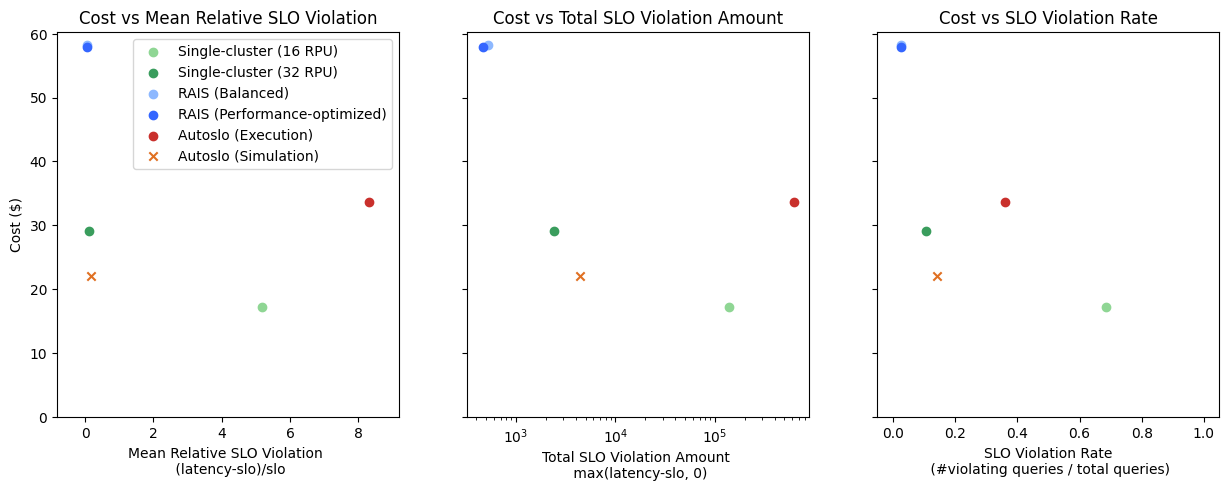

In [63]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

# One subplot per SLO metric:
for name, trace in traces.items():
    cost = float(sum(trace.costs))
    compliance_stats = trace.slo_compliance()
    slo_violation_rate = compliance_stats['violates_slo'].mean()
    total_slo_violation_amount = compliance_stats['violation_amount_s'].sum()
    mean_relative_slo_violation = compliance_stats['violation_relative'].mean()
    axs[2].scatter( slo_violation_rate, cost, label=labels[name], color=colors[name])
    axs[1].scatter(total_slo_violation_amount, cost, label=labels[name], color=colors[name])
    axs[0].scatter( mean_relative_slo_violation, cost, label=labels[name], color=colors[name])

# Also uglily add in the simulation
path = '/home/markakis/chunkbench/data/simulator_runs/redbench_ours/experiment_meta.json'
with open(path, 'r') as f:
    meta = json.load(f)
cost = meta['runs'][0]['total_cost']
slo_violation_rate = meta['runs'][0]['violation_rate']
total_slo_violation_amount = meta['runs'][0]['violation_amount_s']
mean_relative_slo_violation = meta['runs'][0]['violation_relative_mean']
axs[2].scatter( slo_violation_rate, cost, label='Autoslo (Simulation)', color=Palette.dark_orange, marker='x')
axs[1].scatter(total_slo_violation_amount, cost, label='Autoslo (Simulation)', color=Palette.dark_orange, marker='x')
axs[0].scatter( mean_relative_slo_violation, cost, label='Autoslo (Simulation)', color=Palette.dark_orange, marker='x')


# Plot setup
axs[0].set_ylabel('Cost ($)')
axs[0].set_ylim(bottom = 0)
axs[0].set_xlabel('Mean Relative SLO Violation \n (latency-slo)/slo')
axs[1].set_xlabel('Total SLO Violation Amount \n max(latency-slo, 0)')
axs[2].set_xlabel('SLO Violation Rate\n (#violating queries / total queries)')
axs[0].set_title('Cost vs Mean Relative SLO Violation')
axs[1].set_title('Cost vs Total SLO Violation Amount')
axs[2].set_title('Cost vs SLO Violation Rate')

axs[0].legend()

relative_eps = 0.05
# Adjust min/max so that there is the specified amount of relative padding 
# around the points. This is just for aesthetics.
ax0_range = axs[0].get_xlim()[1] - axs[0].get_xlim()[0]
new_min = axs[0].get_xlim()[0] - relative_eps * ax0_range
new_max = axs[0].get_xlim()[1] + relative_eps * ax0_range
axs[0].set_xlim(new_min, new_max)

axs[1].set_xscale('log')

ax2_range = 1
new_min =  - relative_eps
new_max = 1 + relative_eps
axs[2].set_xlim(new_min, new_max)

plt.savefig('cost_vs_compliance.png', bbox_inches='tight', dpi=300)
plt.show()

In [21]:
(df['charged_seconds'].sum() + df['charged_extra_compute_for_automatic_optimization_seconds'].sum()) /3600 * 0.375

np.float64(57.92666666666666)